# Mi loco estamos crazy
## real


In [46]:
import mne
from mne.decoding import CSP
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsOneClassifier 
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import ShuffleSplit, cross_val_score, cross_validate, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.metrics import ConfusionMatrixDisplay

In [47]:
def balance_clases(x_train, y_train):
    classes, counts = np.unique(y_train, return_counts=True)
    min_count = counts.min()

    indices = []

    for c in classes:
        class_idx = np.where(y_train == c)[0]
        sampled_idx = np.random.choice(class_idx, min_count, replace=False)
        indices.extend(sampled_idx)

    indices = np.array(indices)

    x_bal = x_train[indices]
    y_bal = y_train[indices]

    shuffle_idx = np.random.permutation(len(y_bal))

    x_train_balanced = x_bal[shuffle_idx]
    y_train_balanced = y_bal[shuffle_idx]
    return x_bal, y_bal

def fourier(x_algo, y_algo):
    y_cambio = (y_algo != 0).astype(int)

    sfreq = 250
    fmin, fmax = 8, 30
    n_windows, n_channels, n_samples = x_algo.shape
    freqs = np.fft.rfftfreq(n_samples, 1/sfreq)
    band_mask = (freqs >= fmin) & (freqs <= fmax)
    
    # FFT por ventana y canal
    X_fft = np.abs(np.fft.rfft(x_algo, axis=2))[:, :, band_mask]**2
    X_fft = np.log(X_fft + 1e-12)
    
    # Aplanar para clasificador
    x_cambio = X_fft.reshape(n_windows, -1)
    
    return x_cambio, y_cambio

(5241, 8, 375) (5241,)


Quieres entrenar manera simple (1), manera Gonzalo (2), o manera Robert (3)? Dime:  3


Computing rank from data with rank=None
    Using tolerance 14 (2.2e-16 eps * 8 dim * 7.7e+15  max singular value)
    Estimated rank (data): 8
    data: rank 8 computed from 8 data channels with 0 projectors
Reducing data rank from 8 -> 8
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
0.6203703703703703
Matriz de confusión:
 [[126  90]
 [ 74 142]]


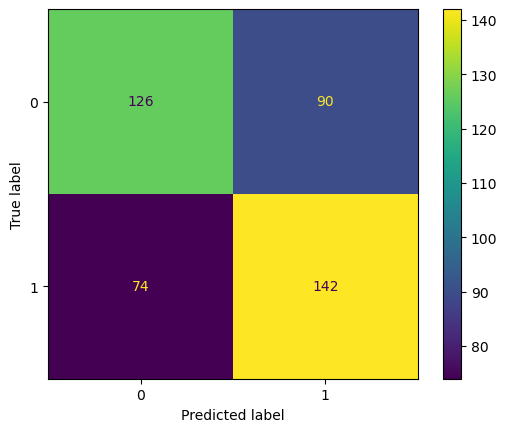

In [48]:
#main
data = np.load("datos_procesados.npz")

x = data["x"]
y = data["y"]

print(x.shape, y.shape)

#x_train, y_train = balance_clases (x_train, y_train)
#x_test, y_test = balance_clases (x_test, y_test)

x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y,
    test_size=0.2,   # 20% para validación
    stratify=y,      # misma distribución de clases en tanto en train como test 
    random_state=36  # para reproducibilidad
)

x_feat_train = np.log(np.var(x_train, axis=2) + 1e-12)   #(num ventanas, num canales)
x_feat_test = np.log(np.var(x_test, axis=2) + 1e-12)   #(num ventanas, num canales)

type_training=int(input("Quieres entrenar manera simple (1), manera Gonzalo (2), o manera Robert (3)? Dime: "))
models=[SVC(kernel="linear"), LinearDiscriminantAnalysis(), RandomForestClassifier(class_weight='balanced'),]

if type_training==1:
    for model in models:
            
        clf = Pipeline([
            ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
            ("model", model)
        ])
    
        clf.fit(x_train, y_train)
    
        print(model)
        print("Accuracy:", clf.score(x_test, y_test))
    
        y_pred = clf.predict(x_test)
    
        cm = confusion_matrix(y_test, y_pred)
        print("Matriz de confusión:\n", cm)
    
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()

elif type_training==2:
    for model in models:
        pipe = Pipeline([
            ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
            ("model", model)])
        clf=OneVsRestClassifier(pipe)
        clf.fit(x_train, y_train)
        print(model)
        print(clf.score(x_test , y_test))

        y_pred = clf.predict(x_test)
        cm = confusion_matrix(y_test, y_pred)
        print("Matriz de confusión:\n", cm)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()

elif type_training==3:

    y_bin_train = (y_train != 0).astype(int)
    y_bin_test = (y_test != 0).astype(int)

    x_train, y_bin_train = balance_clases (x_train, y_bin_train)
    x_test, y_bin_test = balance_clases (x_test, y_bin_test)
    
    clf_reposo = Pipeline([("csp",CSP(n_components=4, reg=None, log= True, norm_trace=False)),("lda", RandomForestClassifier())])
    clf_reposo.fit(x_train, y_bin_train)
    print(clf_reposo.score(x_test , y_bin_test))


    y_pred_rest = clf_reposo.predict(x_test)
    cm = confusion_matrix(y_bin_test, y_pred_rest)
    print("Matriz de confusión:\n", cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    
else:
    print("tendrías que haber dado 1, 2 o 3")